In [158]:
using NPZ
pixel = 1000
data = npzread("data/pixels_exp/dA_pixel_$pixel.npz")

z_range = data["z_range"]
dA = data["dA"]
dA_z = data["dA_z"]
dA_zz = data["dA_zz"]
dA_zzz = data["dA_zzz"]

2001-element Vector{Float64}:
     2.7512081884426817e7
     2.733791041160401e7
     2.7164268669184808e7
     2.700651610707369e7
     2.6837066309258524e7
     2.6669853647847775e7
     2.650482355620535e7
     2.6341991350524563e7
     2.6181291275053788e7
     2.6035081763191964e7
     ⋮
 28043.475035763175
 28042.433107814002
 28041.39120542939
 28040.349328415094
 28039.307476955353
 28038.265651017435
 28037.223850828326
 28036.182075711517
 28035.140326220706

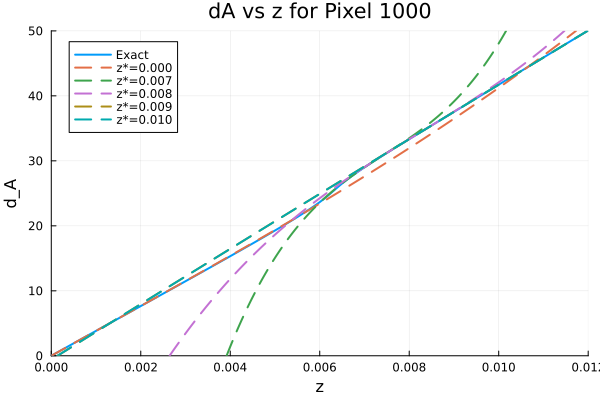

In [160]:
using Plots
plot(z_range, dA, label="Exact", lw=2)
#plot!(z_range, dA_exp_000, label="Exp 0.00", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_001, label="Exp 0.01", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_002, label="Exp 0.02", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_003, label="Exp 0.03", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_004, label="Exp 0.04", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_005, label="Exp 0.05", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_006, label="Exp 0.06", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_007, label="Exp 0.07", lw=1, ls=:dash)
#plot!(z_range, dA_exp_008, label="Exp 0.08", lw=1, ls=:dash)
#plot!(z_range, dA_exp_009, label="Exp 0.09", lw=1, ls=:dash)
#plot!(z_range, dA_exp_010, label="Exp 0.10", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_011, label="Exp 0.11", lw=0.5, ls=:dash)
#plot!(z_range, dA_exp_012, label="Exp 0.12", lw=0.5, ls=:dash)
function dA_exp(z)
    z_eval = round(Int, z *1e5 + 1)
    return @. dA[z_eval] + dA_z[z_eval] * (z_range-z) + 0.5 * dA_zz[z_eval] * (z_range-z)^2 + (1/6) * dA_zzz[z_eval] * (z_range-z)^3
end
plot!(z_range, dA_exp(0.000), label="z*=0.000", lw=2, ls=:dash)
plot!(z_range, dA_exp(0.007), label="z*=0.007", lw=2, ls=:dash)
plot!(z_range, dA_exp(0.008), label="z*=0.008", lw=2, ls=:dash)
plot!(z_range, dA_exp(0.009), label="z*=0.009", lw=2, ls=:dash)
plot!(z_range, dA_exp(0.010), label="z*=0.010", lw=2, ls=:dash)

xlabel!("z")
ylabel!("d_A")
title!("dA vs z for Pixel $pixel")
xlims!(0, 0.012)
ylims!(0, 50)

In [ ]:
using Healpix, NPZ

Nside = 16
npix  = nside2npix(Nside)

# Load first pixel to get size
data0   = npzread("data/pixels_exp/dA_pixel_1.npz")
z_range = data0["z_range"]
nz      = length(z_range)

# Store all data: (pixel, redshift)
dA_map = zeros(Float64, npix, nz)
dA_z_map = zeros(Float64, npix, nz)
dA_zz_map = zeros(Float64, npix, nz)
dA_zzz_map = zeros(Float64, npix, nz)

# Fill array
for pixel in 1:npix
    data = npzread("data/pixels_exp/dA_pixel_$pixel.npz")
    dA_map[pixel, :] = data["dA"]
    dA_z_map[pixel, :] = data["dA_z"]
    dA_zz_map[pixel, :] = data["dA_zz"]
    dA_zzz_map[pixel, :] = data["dA_zzz"]
end

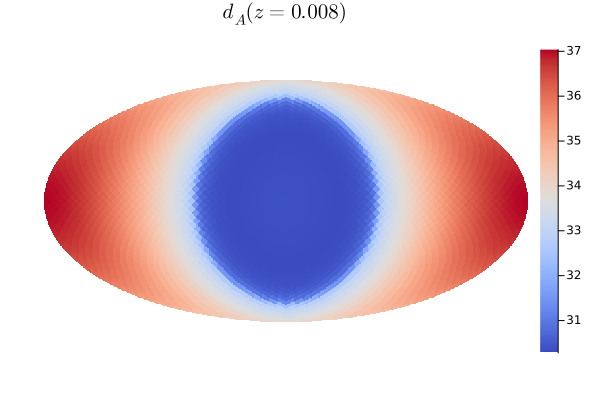

In [144]:
using Healpix

# Create empty map
map = HealpixMap{Float64, NestedOrder}(Nside)

# Fill it
map[:] = dA_map[:, 801]

# Plot
pmap = plot(
    map,
    Healpix.mollweide,
    title = L"d_A(z=0.008)",
    color = :coolwarm,
    framestyle = :none
)

display(pmap)

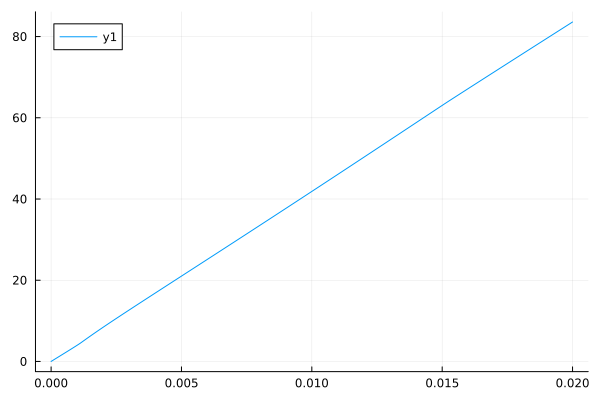

In [130]:
using Statistics

plot(z_range, mean(dA_map, dims=1)[:])


In [175]:
function dA_exp_fixed(z, iz0)
    z0 = z_range[iz0]                # expansion point
    Δz = z - z0                       # distance from expansion

    # pick derivatives at expansion point
    dA_     = dA_map[:, iz0]
    dA_z_   = dA_z_map[:, iz0]
    dA_zz_  = dA_zz_map[:, iz0]
    dA_zzz_ = dA_zzz_map[:, iz0]

    # evaluate Taylor expansion
    return @. dA_ + dA_z_ * Δz + 0.5 * dA_zz_ * Δz^2 + (1/6) * dA_zzz_ * Δz^3
end

full_map = zeros(Float64, npix, nz)

for (i, z) in enumerate(z_range)
    full_map[:, i] = dA_exp_fixed(z, 801)
end

3072×2001 Matrix{Float64}:
 -1.20586   -1.16226   -1.11824   -1.07424   …   84.8052   84.8651   84.925
 -1.89799   -1.85162   -1.80481   -1.75802       89.3256   89.3956   89.4657
 -0.819897  -0.77784   -0.735372  -0.692919      82.1457   82.1997   82.2537
 -1.28369   -1.23979   -1.19545   -1.15114       85.3146   85.3757   85.4367
 -3.15978   -3.10836   -3.05645   -3.00459       97.0346   97.122    97.2096
 -5.75337   -5.69159   -5.62926   -5.567     …  111.637   111.758   111.879
 -2.07278   -2.0257    -1.97819   -1.9307        90.4267   90.4991   90.5717
 -3.56276   -3.50972   -3.45619   -3.40271       99.4016   99.4945   99.5874
 -0.569221  -0.528157  -0.486689  -0.445232      80.3636   80.4137   80.4638
 -0.901383  -0.859001  -0.816207  -0.773428      82.7178   82.7731   82.8284
  ⋮                                          ⋱                        ⋮
 -0.569221  -0.528157  -0.486689  -0.445232      80.3636   80.4137   80.4638
 -3.56276   -3.50972   -3.45619   -3.4027        99.4015

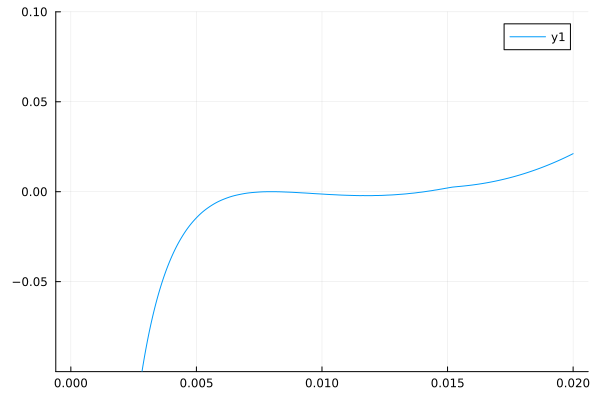

In [182]:
plot(z_range, mean((dA_map .- full_map)./ dA_map, dims=1)[:])
ylims!(-0.1, 0.1)